# Lecture 01 Practice - Linear Algebra

This notebook contains small exercises for working with the ideas from the theory notebook. The tasks are intentionally simple and visual. They focus on seeing the objects and checking computations.

Answers are placed next to the corresponding questions in encoded form. Running an answer cell reveals the explanation. The encoding is only intended to avoid showing the answer immediately.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
np.set_printoptions(precision=3, suppress=True)


In [2]:
import base64
from IPython.display import Markdown, display

ANSWER_KEY = 73

def reveal_answer(encoded):
    raw = base64.b64decode(encoded)
    text = bytes(byte ^ ANSWER_KEY for byte in raw).decode("utf-8")
    display(Markdown(text))


## Exercise 1 - Distances

Implement two functions:

- `l2_distance(a, b)` for Euclidean distance;
- `l1_distance(a, b)` for Manhattan distance.

Test them on `a = (1, 2, 3)` and `b = (4, 0, -1)`.


In [3]:
def l2_distance(a, b):
    a = np.asarray(a)
    b = np.asarray(b)

    return np.sqrt(np.sum(np.abs(a-b)**2))

def l1_distance(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    return np.sum(np.abs(a - b))
    

a = np.array([1, 2, 3])
b = np.array([4, 0, -1])

print("L2:", l2_distance(a, b))
print("L1:", l1_distance(a, b))


L2: 5.385164807134504
L1: 9


## Exercise 2 - Vector Arithmetic

Let `u = (2, -1)` and `v = (-1, 3)`.

Compute:

- `u + v`
- `u - v`
- `3u`
- the norm of `v`


In [9]:
u = np.array([2, -1])
v = np.array([-1, 3])



print(u+v)
print(u-v)
print(3*u)
print(np.sqrt(np.sum(v**2)))

[1 2]
[ 3 -4]
[ 6 -3]
3.1622776601683795


## Exercise 3 - Dot Product and Angle

Write a function `angle_between(a, b)` that returns the angle in radians between two non-zero vectors.

Use the identity:

$$\cos(\theta)=\frac{a \cdot b}{||a||||b||}.$$

Numerical rounding can make cosine values slightly smaller than -1 or slightly larger than 1, so `np.clip` is useful before applying `np.arccos`.


In [8]:
def angle_between(a, b):
    dot_product = np.sum(a * b)

    norm_a = np.sqrt(np.sum(a**2))
    norm_b = np.sqrt(np.sum(b**2))

    cos_theta = dot_product / (norm_a * norm_b)

    cos_theta = np.clip(cos_theta, -1, 1)

    angle = np.arccos(cos_theta)

    return angle

print(angle_between(np.array([1, 0]), np.array([0, 1])))
print(angle_between(np.array([1, 0]), np.array([1, 1])))


1.5707963267948966
0.7853981633974484


## Exercise 4 - Projection

Compute the projection of `b = (2, 3)` onto `a = (4, 0)`.

Then compute the residual `b - projection`. Check that the residual is orthogonal to `a`.


In [11]:
a = np.array([4, 0])
b = np.array([2, 3])

projection = (np.dot(a, b) / np.dot(a, a)) * a
residual = b - projection

print(projection)
print(residual)
print(np.dot(a, residual))

[2. 0.]
[0. 3.]
0.0


## Exercise 5 - Decision Boundary

For the score

$$s(x)=2x_1-x_2-1,$$

find whether each point is on the positive side, negative side, or boundary:

`(0, 0)`, `(1, 1)`, `(2, 1)`, `(-1, -4)`.

Then draw the boundary line.


[-1  0  2  1]
[0 0] negative
[1 1] boundary
[2 1] positive
[-1 -4] positive


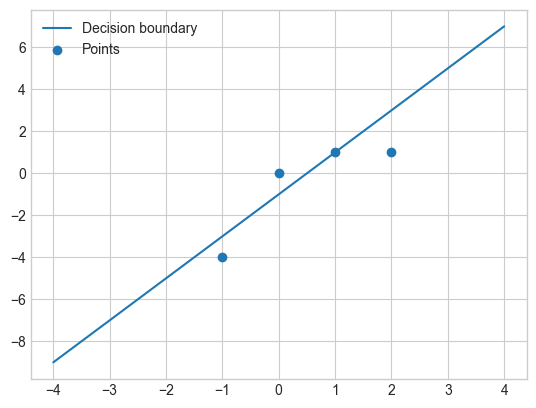

In [12]:
points = np.array([[0, 0], [1, 1], [2, 1], [-1, -4]])
w= np.array([2,-1])
bias = -1
X1 = points[:, 0]
X2 = points[:, 1]
score = w[0]*X1+w[1]*X2+bias 

# Compute the scores and classify the points.
print(score)

for point, s in zip(points, score):
    if s > 0:
        print(point, "positive")
    elif s < 0:
        print(point, "negative")
    else:
        print(point, "boundary")


# Then draw the line 2*x1 - x2 - 1 = 0.

x1 = np.linspace(-4, 4, 200)
x2 = 2 * x1 - 1

plt.plot(x1, x2, label="Decision boundary")
plt.scatter(X1, X2, label="Points")

plt.legend()
plt.show()

### Encoded answer - Exercise 5


## Exercise 6 - Matrix Transformation

Create a matrix that stretches the x-axis by 2 and compresses the y-axis by 0.5.

Apply it to the square with corners:

`(-1, -1)`, `(1, -1)`, `(1, 1)`, `(-1, 1)`.

Plot the original and transformed square.


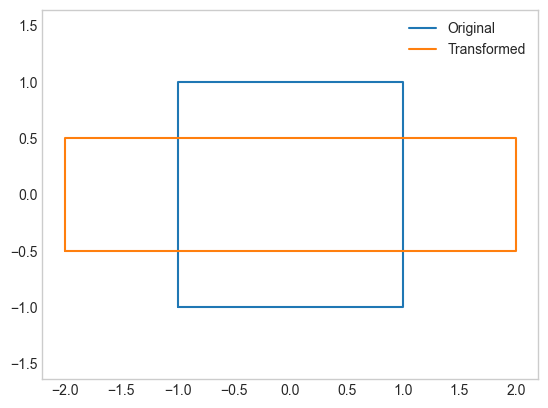

In [14]:
square = np.array([
    [-1, -1],
    [1, -1],
    [1, 1],
    [-1, 1],
    [-1, -1]
])

# Define A
A = np.array([
    [2, 0],
    [0, 0.5]
])

# Transform the square
transformed_square = square @ A.T

# Plot both
plt.plot(square[:, 0], square[:, 1], label="Original")

plt.plot(
    transformed_square[:, 0],
    transformed_square[:, 1],
    label="Transformed"
)

plt.axis("equal")
plt.legend()
plt.grid()

plt.show()